In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/housing.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20640, 10)

Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Dataset Shape: (20640, 10)

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

X Shape: (20640, 8)
y Shape: (20640, 1)

Training samples: 16512
Testing samples: 4128
Iteration    0 | Loss: 28148711615.5157
Iteration  100 | Loss: 6428462204.4410
Iteration  200 | Loss: 3407780742.3855
Iteration  300 | Loss: 2924900807.8507
Iteration  400 | Loss: 2800275885.5155
Iteration  500 | Loss: 2734588405.0942
Iteration  600 | Loss: 2684863844.0684
Iteration  700 | Loss: 2643766794.5008
Iteration  800 | Loss: 2609189695.4209
Iteration  900 | Loss: 2579960054.2125

Final weights (theta):
[207185.74888449 -43506.87438121 -48761.81298927  20552.84097594
  -4440.05241154  22169.14141597 -32668.83143497  22408.03638203
  78860.51956515]

Test MSE : 5271411984.5956
Test R^2 : 0.5977

sklearn LinearRegression R^2: 0.6139

Saved plots to gradient_descent_housing_plots.png


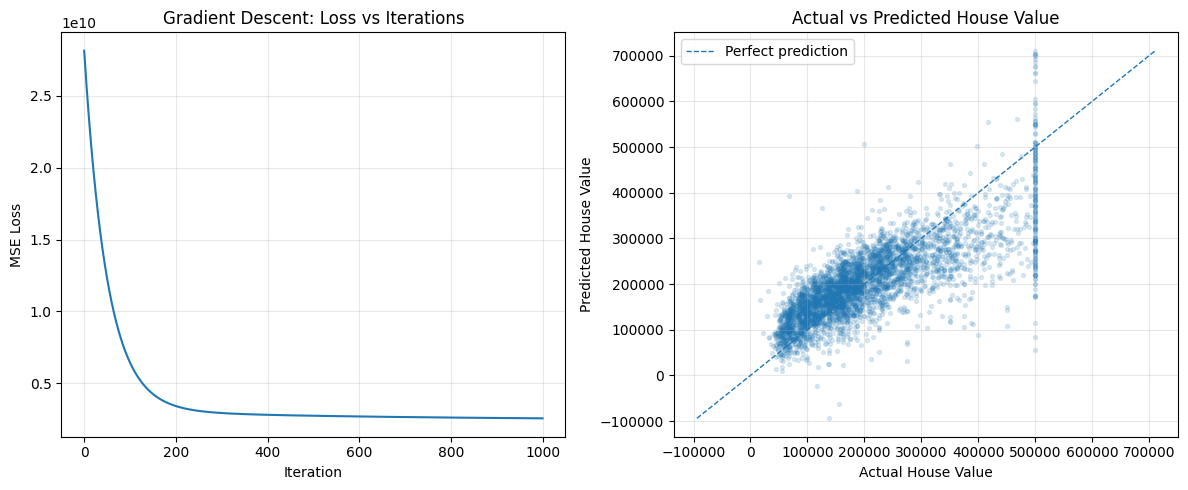

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------

df = pd.read_csv("/content/housing.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


# ---------------------------------------------------------
# 2. Select target and features
# ---------------------------------------------------------

target_col = "median_house_value"

# Drop target and categorical column
drop_cols = [target_col, "ocean_proximity"]

feature_df = df.drop(columns=drop_cols)

# Keep only numerical columns
feature_df = feature_df.select_dtypes(include=[np.number])


# ---------------------------------------------------------
# 3. Handle missing values
# ---------------------------------------------------------

feature_df = feature_df.fillna(feature_df.median())


# Create X and y
X = feature_df.values
y = df[target_col].values.reshape(-1, 1)


print("\nFeatures:")
print(feature_df.columns.tolist())

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


# ---------------------------------------------------------
# 4. Train/Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ---------------------------------------------------------
# 5. Feature Scaling
# ---------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Add bias/intercept column

X_train_b = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_b = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]


# ---------------------------------------------------------
# 6. Gradient Descent Implementation
# ---------------------------------------------------------

def gradient_descent(X, y, lr=0.01, n_iters=1000):

    m, n = X.shape

    # Initialize weights
    theta = np.zeros((n, 1))

    losses = []

    for i in range(n_iters):

        # Prediction
        y_pred = X @ theta

        # Error
        error = y_pred - y

        # MSE Loss
        loss = (1 / (2 * m)) * np.sum(error ** 2)

        losses.append(loss)

        # Gradient
        gradient = (1 / m) * (X.T @ error)

        # Update weights
        theta -= lr * gradient

        if i % 100 == 0:
            print(
                f"Iteration {i:4d} | Loss: {loss:.4f}"
            )

    return theta, losses


# Run Gradient Descent

theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)


# ---------------------------------------------------------
# 7. Evaluate Model
# ---------------------------------------------------------

y_pred = X_test_b @ theta


mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")


# ---------------------------------------------------------
# 8. Compare with sklearn Linear Regression
# ---------------------------------------------------------

from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()

sk_model.fit(
    X_train,
    y_train
)

sk_pred = sk_model.predict(X_test)

sk_r2 = r2_score(
    y_test,
    sk_pred
)

print(
    f"\nsklearn LinearRegression R^2: {sk_r2:.4f}"
)


# ---------------------------------------------------------
# 9. Plots
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# (a) Gradient Descent Loss Curve

axes[0].plot(
    range(len(losses)),
    losses
)

axes[0].set_title(
    "Gradient Descent: Loss vs Iterations"
)

axes[0].set_xlabel(
    "Iteration"
)

axes[0].set_ylabel(
    "MSE Loss"
)

axes[0].grid(
    alpha=0.3
)


# (b) Actual vs Predicted

axes[1].scatter(
    y_test,
    y_pred,
    alpha=0.15,
    s=8
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[1].plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)

axes[1].set_title(
    "Actual vs Predicted House Value"
)

axes[1].set_xlabel(
    "Actual House Value"
)

axes[1].set_ylabel(
    "Predicted House Value"
)

axes[1].legend()

axes[1].grid(
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    "gradient_descent_housing_plots.png",
    dpi=150
)

print(
    "\nSaved plots to gradient_descent_housing_plots.png"
)

plt.show()